# nb05 — честная рампа: сколько эталона держится на модели сайзинга

**Вопрос.** Paper-бот за 25 дней (2026-07-08…08-01) сделал ≈0 на 459 сделках, при том что
эталон обещает Sharpe ~3 и 6.3× на дистанции. Разбор логов бота показал: per-trade edge жив
(equal-weight +0.32%/сделку), но notional-weighted −0.06% — выигрышные сделки шли крошечным
размером. Причина — рампа scale-in, которой **в эталоне нет**.

**Что проверяем здесь.** Эталон моделирует рампу в *цене* (средневзвешенный вход), но ставит
на каждую сделку **полный** `f·eq` независимо от того, сколько траншей реально залилось.
Бот так не может. Вопрос: сколько от Sharpe 3.04 / 6.2× остаётся, если платить за рампу капиталом.

**Метод.** Никаких пересборок сигналов и никаких правок движка. Достаём число реализованных
траншей `k` дешёвым проходом (`_extract_k.py`, детектор импортирован из `_build_signals.py`,
не переписан), джойним на готовый parquet и переразмериваем через штатный `run_dca(ffrac=...)`.

In [1]:
import sys, os
if os.path.basename(os.getcwd()) != "pump_dump_v2":
    os.chdir(r"C:\projects\researchlab\notebooks\pump_dump_v2")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from _engine import load_signals, build_book, run_dca, metrics, naive
from _lab import show
pd.set_option("display.width", 250)

PUMP, DUMP = load_signals()
BOOK = build_book(PUMP, DUMP)                      # WF-фильтр, hold-to-horizon = эталон nb00
K = pd.read_parquet("_out/tranche_k.parquet")[["sym", "entry", "k"]]
K["entry"] = naive(K["entry"])                     # load_signals снимает tz — совпадаем

B = BOOK.merge(K, on=["sym", "entry"], how="left")
miss = int(B.k.isna().sum())
print(f"книга эталона      {len(BOOK)} сделок")
print(f"джойн k            покрытие {(1-miss/len(B))*100:.3f}%  (не нашлось {miss})")
print(f"промахи все на     {sorted(B[B.k.isna()].entry.dt.date.unique())}  <- граница загрузки месяца, дропаем")
B = B.dropna(subset=["k"]).reset_index(drop=True)
print(f"работаем на        {len(B)} сделках (pump {(B.stream=='pump').sum()} / dump {(B.stream=='dump').sum()})")

книга эталона      14509 сделок
джойн k            покрытие 99.848%  (не нашлось 22)
промахи все на     [datetime.date(2026, 6, 1)]  <- граница загрузки месяца, дропаем
работаем на        14487 сделках (pump 10218 / dump 4269)


## 1. В чём ровно расхождение

Эталон, `_build_signals.py:135-137` — рампа есть, но только в цене:

```python
pos = fills_time(...) / fills_price(...)              # минуты заливок кластера
ws  = np.arange(1, len(pr)+1, float); ws /= ws.sum()  # веса 1,2,…,k
avg = (ws*pr).sum()                                   # средняя цена входа
```

Движок, `_engine.py:96` — размер полный, всегда: `desired = f*eq`.

Бот, `pump_fade_bot/strategy.py:87-92`:

```python
base    = target * 0.05
desired = base * (pos.n_tranches + 1)     # 5%, 10%, 15%, … от target
```

Накопленным итогом `target · min(1, 0.05·k(k+1)/2)`. Форма рампы одинаковая, цена входа
считается одинаково. **Различие ровно в одном множителе — доле развёрнутого капитала.**

In [2]:
def ramp_frac(k, base=0.05):
    """Доля целевого размера после k траншей: base*(1+2+..+k), обрезано единицей."""
    return np.minimum(1.0, base * k * (k + 1) / 2)

print("заполнение размера по числу траншей (base=0.05, как у бота):")
print(pd.DataFrame({"k": range(1, 8),
                    "% от target": (ramp_frac(np.arange(1, 8)) * 100).round(0)}).to_string(index=False))

print("\nраспределение k в книге эталона:")
t = B.groupby("stream").k.describe()[["count", "mean", "50%", "max"]]
t["ramp fill mean %"] = [ramp_frac(B[B.stream == s].k.values).mean() * 100 for s in t.index]
t["ramp fill median %"] = [np.median(ramp_frac(B[B.stream == s].k.values)) * 100 for s in t.index]
t["% на полном размере"] = [(ramp_frac(B[B.stream == s].k.values) >= 1).mean() * 100 for s in t.index]
print(t.round(1).to_string())

bot = pd.read_json(r"C:\projects\pump_fade_bot\server.logs\trades_agg.jsonl", lines=True)
bot["leg"] = np.where(bot.side == "short", "pump", "dump")
print("\nсверка с фактом бота за июль (target = 5% pump / 3% dump от $1000):")
for leg, tgt in [("dump", 30.0), ("pump", 50.0)]:
    bo = bot[bot.leg == leg]
    r = B[B.stream == leg]
    print(f"  {leg:5s} эталон-книга: медиана k={int(r.k.median())}, среднее заполнение "
          f"{ramp_frac(r.k.values).mean()*100:5.1f}%  |  бот факт: медиана k={int(bo.n_tranches.median())}, "
          f"заполнение {bo.notional.mean()/tgt*100:5.1f}%")

заполнение размера по числу траншей (base=0.05, как у бота):
 k  % от target
 1          5.0
 2         15.0
 3         30.0
 4         50.0
 5         75.0
 6        100.0
 7        100.0

распределение k в книге эталона:
          count  mean  50%   max  ramp fill mean %  ramp fill median %  % на полном размере
stream                                                                                     
dump     4269.0   1.8  1.0  19.0              14.8                 5.0                  2.9
pump    10218.0   6.4  4.0  76.0              54.3                50.0                 40.7

сверка с фактом бота за июль (target = 5% pump / 3% dump от $1000):
  dump  эталон-книга: медиана k=1, среднее заполнение  14.8%  |  бот факт: медиана k=1, заполнение  20.1%
  pump  эталон-книга: медиана k=4, среднее заполнение  54.3%  |  бот факт: медиана k=6, заполнение  71.7%


**Сходится.** Дамп-нога в эталоне при честной рампе развернула бы в среднем ~15% планового
размера (медиана — 5%, то есть один транш), у бота по факту 20%. Памп-нога ~53% против 72%.

Расхождение эталон-vs-бот по этой оси — не расхождение вовсе: бот делает ровно то, что следует
из данных эталона. Завышает **эталон**.

## 2. Лесенка: пять моделей сайзинга

- `full` — как сейчас в `run_dca`: полный `f·eq` всегда. Контрольная точка, должна воспроизвести nb00.
- `ramp 0.05` — честная рампа бота.
- `front-load 0.20 / 0.40 / 0.60` — тот же механизм, но первый транш крупнее. Это проверка
  рекомендации «фронт-лоад» *до* того, как трогать код бота.

In [3]:
MODES = {"safe": (0.03, 0.03), "med": (0.04, 0.03), "agg": (0.05, 0.03), "sagg": (0.08, 0.03)}
SIZ = {"full (эталон сейчас)": None, "ramp 0.05 (= бот)": 0.05,
       "front-load 0.20": 0.20, "front-load 0.40": 0.40, "front-load 0.60": 0.60}
is_p = (B.stream == "pump").values
kv = B.k.values

def ffrac_for(base, fp, fd, mask=None, k=kv, isp=is_p):
    f = np.where(isp, fp, fd) * (1.0 if base is None else ramp_frac(k, base))
    return f if mask is None else np.where(mask, f, 0.0)

rows = []; REF = {}
for sname, base in SIZ.items():
    for mode, (fp, fd) in MODES.items():
        m = metrics(run_dca(B, ffrac=ffrac_for(base, fp, fd)), "")
        rows.append(dict(sizing=sname, mode=mode, **m))
        if base is None and mode == "agg":
            REF = m
T = pd.DataFrame(rows)
for col in ["mult", "Sharpe", "maxDD"]:
    print(f"=== {col} ===")
    print(T.pivot(index="sizing", columns="mode", values=col)
           .reindex(list(SIZ))[["safe", "med", "agg", "sagg"]].to_string(), "\n")

print(f"КОНТРОЛЬ воспроизведения nb00 (agg): mult {REF['mult']} / Sharpe {REF['Sharpe']} / maxDD {REF['maxDD']}")
print(f"                    README заявляет: mult 6.2x / Sharpe 3.04 / maxDD -21.1%")

=== mult ===
mode                  safe   med   agg  sagg
sizing                                      
full (эталон сейчас)  4.6x  5.5x  6.3x  8.2x
ramp 0.05 (= бот)     2.1x  2.4x  2.6x  3.4x
front-load 0.20       2.9x  3.4x  3.9x  5.0x
front-load 0.40       3.5x  4.2x  4.7x  6.0x
front-load 0.60       3.9x  4.6x  5.3x  6.8x 

=== Sharpe ===
mode                  safe   med   agg  sagg
sizing                                      
full (эталон сейчас)  3.21  3.17  3.05  2.76
ramp 0.05 (= бот)     2.15  2.24  2.24  2.16
front-load 0.20       2.82  2.82  2.75  2.51
front-load 0.40       3.07  3.04  2.93  2.60
front-load 0.60       3.16  3.12  3.00  2.68 

=== maxDD ===
mode                    safe     med     agg    sagg
sizing                                              
full (эталон сейчас)  -13.6%  -17.3%  -21.1%  -31.5%
ramp 0.05 (= бот)     -10.9%  -13.6%  -16.1%  -23.4%
front-load 0.20        -9.5%  -13.0%  -16.2%  -23.1%
front-load 0.40        -6.3%   -9.2%  -12.2%  -20.2%
front-

**Главный результат.** Честная рампа снимает примерно треть Sharpe и больше половины роста:
`agg` 6.3× / 3.05 → **2.6× / 2.24**. Просадка при этом падает (−21.1% → −16.1%) — просто потому,
что в рынке меньше денег.

Фронт-лоад 0.40 возвращает почти всё (4.7× / 2.93) **и даёт лучшую просадку из всех моделей**
(−12.2% против −21.1% у full). Это уже готовая рекомендация для бота.

In [4]:
print("=== разложение по ногам (веса agg: pump 5% / dump 3%) ===")
for legname, mask in [("pump only", is_p), ("dump only", ~is_p), ("combined", np.ones(len(B), bool))]:
    for sname, base in [("full", None), ("ramp 0.05", 0.05), ("front 0.40", 0.40)]:
        m = metrics(run_dca(B, ffrac=ffrac_for(base, 0.05, 0.03, mask)), "")
        print(f"  {legname:10s} {sname:10s} mult {m['mult']:>6s}  Sharpe {m['Sharpe']:>5s}  maxDD {m['maxDD']:>7s}")
    print()

=== разложение по ногам (веса agg: pump 5% / dump 3%) ===
  pump only  full       mult   2.9x  Sharpe  2.29  maxDD  -21.8%


  pump only  ramp 0.05  mult   1.9x  Sharpe  2.04  maxDD  -17.1%
  pump only  front 0.40 mult   2.6x  Sharpe  2.30  maxDD  -17.9%



  dump only  full       mult   2.0x  Sharpe  1.62  maxDD  -12.9%
  dump only  ramp 0.05  mult   1.2x  Sharpe  0.82  maxDD   -5.9%
  dump only  front 0.40 mult   1.6x  Sharpe  1.49  maxDD   -6.5%



  combined   full       mult   6.3x  Sharpe  3.05  maxDD  -21.1%
  combined   ramp 0.05  mult   2.6x  Sharpe  2.24  maxDD  -16.1%


  combined   front 0.40 mult   4.7x  Sharpe  2.93  maxDD  -12.2%



**Пострадала дамп-нога, и сильно: Sharpe 1.62 → 0.82.** Памп-нога почти не заметила
(2.29 → 2.04) — её рампа привязана к *времени* (транш на минуту кластера), а дампова к
*неблагоприятной цене* (транш на каждые −2% вниз). Поэтому у дампа медиана k=1 и капитал
не успевает развернуться.

Именно та нога, которую исследование называло «настоящий edge», держится на модели сайзинга.

In [5]:
cut = B.entry.quantile(0.40)
Bo = B[B.entry >= cut].reset_index(drop=True)
isp2, kv2 = (Bo.stream == "pump").values, Bo.k.values
print(f"OOS-окно (с 40%-метки, WF-фильтр живой): {Bo.entry.min().date()} .. {Bo.entry.max().date()}, {len(Bo)} сделок\n")
for sname, base in SIZ.items():
    line = f"  {sname:22s}"
    for mode in ["agg", "sagg"]:
        fp, fd = MODES[mode]
        m = metrics(run_dca(Bo, ffrac=ffrac_for(base, fp, fd, k=kv2, isp=isp2)), "")
        line += f" | {mode}: {m['mult']:>5s} Sh {m['Sharpe']:>5s} DD {m['maxDD']:>7s}"
    print(line)

OOS-окно (с 40%-метки, WF-фильтр живой): 2024-08-05 .. 2026-06-30, 8782 сделок



  full (эталон сейчас)   | agg:  5.2x Sh  3.38 DD  -19.3% | sagg:  6.8x Sh  3.16 DD  -29.3%


  ramp 0.05 (= бот)      | agg:  2.3x Sh  2.35 DD  -16.3% | sagg:  3.0x Sh  2.37 DD  -24.0%


  front-load 0.20        | agg:  3.2x Sh  2.87 DD  -16.5% | sagg:  4.1x Sh  2.75 DD  -25.1%


  front-load 0.40        | agg:  3.9x Sh  3.16 DD  -12.1% | sagg:  5.0x Sh  2.92 DD  -20.1%


  front-load 0.60        | agg:  4.3x Sh  3.27 DD  -12.8% | sagg:  5.5x Sh  3.01 DD  -21.3%


OOS та же картина: `agg` 5.2× / 3.38 → 2.3× / 2.35 на честной рампе; фронт-лоад 0.40
возвращает 3.9× / 3.16 при просадке −12.1% против −19.3% у full.

## 3. А может, рампа сама по себе полезна?

Рампа не только режет капитал — она ещё и **перераспределяет** его в сторону сделок с большим `k`.
Если глубокое усреднение окупается, это плюс, и тогда потеря Sharpe — цена, а не дефект.
Проверяем связку `k` ↔ исход, и сразу сверяем с тем, что получил бот.

In [6]:
for leg in ["dump", "pump"]:
    r = B[B.stream == leg]; bo = bot[bot.leg == leg]
    print(f"-- {leg} --  research corr(k,pnl) = {r.k.corr(r.pnl):+.3f} (n={len(r)})   "
          f"бот-июль corr(k,ret) = {bo.n_tranches.corr(bo.ret_pct):+.3f} (n={len(bo)})")
    rg = r.groupby(r.k.clip(upper=6)).pnl.agg(n="size", mean=lambda s: s.mean() * 100,
                                              median=lambda s: s.median() * 100)
    bg = bo.groupby(bo.n_tranches.clip(upper=6)).ret_pct.agg(n="size", mean="mean")
    print(pd.DataFrame({"research n": rg.n, "research mean %": rg["mean"].round(2),
                        "research med %": rg["median"].round(2),
                        "бот n": bg.n, "бот mean %": bg["mean"].round(2),
                        "заполнение %": (ramp_frac(rg.index.values) * 100).round(0)}).to_string(), "\n")

D = B[B.stream == "dump"]
w = ramp_frac(D.k.values)
print(f"dump, research: equal-weight {D.pnl.mean()*100:+.3f}%   ramp-weighted {np.average(D.pnl, weights=w)*100:+.3f}%"
      f"   -> рампа как ОТБОР даёт {(np.average(D.pnl, weights=w)-D.pnl.mean())*100:+.2f}pp")

-- dump --  research corr(k,pnl) = +0.337 (n=4269)   бот-июль corr(k,ret) = -0.123 (n=282)
     research n  research mean %  research med %  бот n  бот mean %  заполнение %
1.0        2570             2.59            3.00    146        2.15           5.0
2.0         936             5.14            5.22     68       -0.62          15.0
3.0         461             8.19            8.22     27       -6.74          30.0
4.0         130            11.19           10.74     12       -1.52          50.0
5.0          47            13.27            4.72      9       -0.16          75.0
6.0         125            33.54           37.68     20       -4.72         100.0 

-- pump --  research corr(k,pnl) = +0.004 (n=10218)   бот-июль corr(k,ret) = -0.028 (n=177)
     research n  research mean %  research med %  бот n  бот mean %  заполнение %
1.0        2500             0.00            0.76     20        2.92           5.0
2.0        1330            -0.10            0.40     12       -2.99          

В research'е связка сильная и положительная (`+0.337`): чем глубже усреднился в дамп, тем
лучше исход — k=1 даёт +2.6%, k≥6 даёт +33%. То есть как **отбор** рампа полезна (+6.9pp), и
теряем мы Sharpe не из-за неё, а из-за недоразвёрнутого капитала.

Но у бота за июль знак обратный (`−0.123`). Прежде чем объявлять это сломом режима — проверим,
отличимо ли это от шума на горизонте одного месяца.

In [7]:
d6 = D[D.k >= 6]
print("### сначала: на чём вообще держится бонус k>=6 в research?")
print(f"  n={len(d6)}  mean {d6.pnl.mean()*100:+.2f}%  median {d6.pnl.median()*100:+.2f}%  win {(d6.pnl>0).mean()*100:.0f}%")
print(f"  символов {d6.sym.nunique()}, но РАЗНЫХ ДНЕЙ всего {d6.entry.dt.date.nunique()} (из ~910 в выборке)")
print(f"  -> это корзина редких событий: глубокие усреднения кучкуются в дни рыночных отскоков\n")

print("### честный тест: распределение corr(k,pnl) по 25-дневным окнам research'а")
recs = []
for d0 in pd.date_range(D.entry.min().normalize(), D.entry.max().normalize() - pd.Timedelta(days=25), freq="1D"):
    wnd = D[(D.entry >= d0) & (D.entry < d0 + pd.Timedelta(days=25))]
    if len(wnd) < 40 or wnd.k.nunique() < 3:
        continue
    recs.append(dict(corr=wnd.k.corr(wnd.pnl),
                     mean_k4p=wnd[wnd.k >= 4].pnl.mean() * 100 if (wnd.k >= 4).any() else np.nan))
W = pd.DataFrame(recs)
bl = bot[bot.leg == "dump"]
bc = bl.n_tranches.corr(bl.ret_pct); k4b = bl[bl.n_tranches >= 4].ret_pct.mean()
print(f"  {len(W)} окон (>=40 дамп-сделок)")
print(f"  corr(k,pnl):        p5 {W['corr'].quantile(.05):+.3f}  медиана {W['corr'].median():+.3f}  "
      f"p95 {W['corr'].quantile(.95):+.3f}  | БОТ {bc:+.3f}  перцентиль {(W['corr']<bc).mean()*100:.0f}%")
print(f"  доля окон с corr<0: {(W['corr']<0).mean()*100:.0f}%")
print(f"  mean pnl k>=4:      p5 {W.mean_k4p.quantile(.05):+.2f}%  медиана {W.mean_k4p.median():+.2f}%  "
      f"p95 {W.mean_k4p.quantile(.95):+.2f}%  | БОТ {k4b:+.2f}%  перцентиль {(W.mean_k4p.dropna()<k4b).mean()*100:.0f}%")
print("\n  ВЫВОД: на месячном горизонте связка k<->исход — монетка (медиана ~0, половина окон")
print("  отрицательные). Июль бота = 30-й перцентиль. Слома режима НЕТ, это нормальный плохой месяц.")
print("  Полновыборочные +0.337 — межрежимный эффект, а не то, на что можно опереться за месяц.")

### сначала: на чём вообще держится бонус k>=6 в research?
  n=125  mean +33.54%  median +37.68%  win 79%
  символов 101, но РАЗНЫХ ДНЕЙ всего 27 (из ~910 в выборке)
  -> это корзина редких событий: глубокие усреднения кучкуются в дни рыночных отскоков

### честный тест: распределение corr(k,pnl) по 25-дневным окнам research'а


  473 окон (>=40 дамп-сделок)
  corr(k,pnl):        p5 -0.586  медиана -0.008  p95 +0.658  | БОТ -0.123  перцентиль 30%
  доля окон с corr<0: 53%
  mean pnl k>=4:      p5 -8.83%  медиана +2.72%  p95 +48.35%  | БОТ -2.78%  перцентиль 13%

  ВЫВОД: на месячном горизонте связка k<->исход — монетка (медиана ~0, половина окон
  отрицательные). Июль бота = 30-й перцентиль. Слома режима НЕТ, это нормальный плохой месяц.
  Полновыборочные +0.337 — межрежимный эффект, а не то, на что можно опереться за месяц.


In [8]:
print("### почему наивный бутстрап здесь соврал бы (записываю, чтобы не наступить снова)")
rng = np.random.default_rng(0)
botk = bl.n_tranches.clip(upper=6).values
pools = {int(k): D[D.k.clip(upper=6) == int(k)].pnl.values for k in np.unique(botk)}
sims = np.array([np.corrcoef(botk, [rng.choice(pools[int(k)]) for k in botk])[0, 1] for _ in range(1500)])
print(f"  бутстрап (независимая тяга из корзин k): p5 {np.quantile(sims,.05):+.3f}  p95 {np.quantile(sims,.95):+.3f}"
      f"  -> P(corr <= {bc:+.3f}) = {(sims<=bc).mean()*100:.2f}%")
print(f"  оконный тест (сохраняет время):          p5 {W['corr'].quantile(.05):+.3f}  p95 {W['corr'].quantile(.95):+.3f}"
      f"  -> перцентиль {(W['corr']<bc).mean()*100:.0f}%")
print("\n  Бутстрап тянет сделки независимо и рвёт временную кластеризацию: дамп-исходы")
print("  сильно скоррелированы внутри дня (рыночный отскок вытягивает все глубокие усреднения")
print("  разом). Эффективный размер выборки поэтому кратно меньше номинального, и бутстрап даёт")
print("  фиктивно узкие интервалы. Правильный null — оконный.")

### почему наивный бутстрап здесь соврал бы (записываю, чтобы не наступить снова)


  бутстрап (независимая тяга из корзин k): p5 +0.283  p95 +0.560  -> P(corr <= -0.123) = 0.00%
  оконный тест (сохраняет время):          p5 -0.586  p95 +0.658  -> перцентиль 30%

  Бутстрап тянет сделки независимо и рвёт временную кластеризацию: дамп-исходы
  сильно скоррелированы внутри дня (рыночный отскок вытягивает все глубокие усреднения
  разом). Эффективный размер выборки поэтому кратно меньше номинального, и бутстрап даёт
  фиктивно узкие интервалы. Правильный null — оконный.


[saved] notebooks\pump_dump_v2\_out\v2_nb05_honest_ramp.png


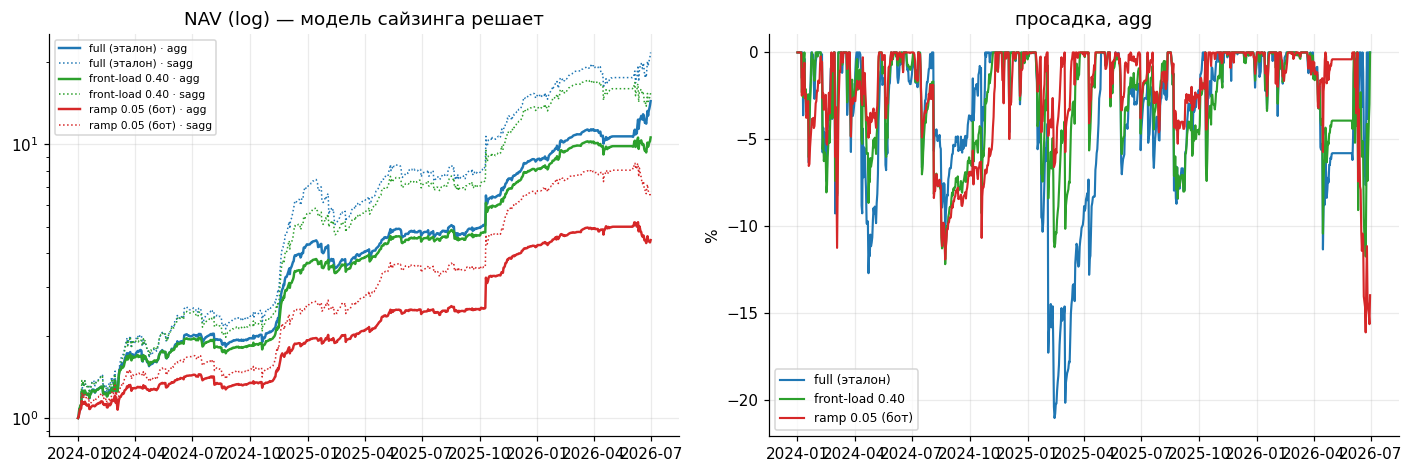

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for base, lab, c in [(None, "full (эталон)", "#1f77b4"), (0.40, "front-load 0.40", "#2ca02c"),
                     (0.05, "ramp 0.05 (бот)", "#d62728")]:
    for i, (mode, ls) in enumerate([("agg", "-"), ("sagg", ":")]):
        fp, fd = MODES[mode]
        nav = run_dca(B, ffrac=ffrac_for(base, fp, fd))["nav"]
        ax[0].plot(nav.index, nav.values, ls, color=c, lw=1.6 if ls == "-" else 1.0,
                   label=f"{lab} · {mode}")
        if mode == "agg":
            ax[1].plot(nav.index, (nav / nav.cummax() - 1).values * 100, color=c, lw=1.4, label=lab)
ax[0].set_yscale("log"); ax[0].set_title("NAV (log) — модель сайзинга решает"); ax[0].legend(fontsize=7)
ax[1].set_title("просадка, agg"); ax[1].set_ylabel("%"); ax[1].legend(fontsize=8)
show("v2_nb05_honest_ramp");

## 4. Замыкание на бота: последний месяц research'а

Бот стартовал 2026-07-08. Выборка research'а кончается 2026-06-30. Смотрим, что две модели
сайзинга говорили про **последний месяц перед запуском** — тот, по которому принималось решение
«работает, запускаем».

In [10]:
print("NAV за последний месяц выборки (2026-06), веса agg:\n")
for name, base in [("full (эталон сейчас)", None), ("ramp 0.05 (= бот)", 0.05), ("front-load 0.40", 0.40)]:
    nav = run_dca(B, ffrac=ffrac_for(base, 0.05, 0.03))["nav"]
    m = nav[nav.index >= "2026-06-01"]
    print(f"  {name:22s} NAV {m.iloc[-1]/m.iloc[0]-1:+7.2%}   внутримесячная просадка {(m/m.cummax()-1).min():+7.2%}")

fact = {m: pd.read_json(rf"C:\projects\pump_fade_bot\server.logs\trades_{m}.jsonl", lines=True).pnl_usd.sum()
        for m in ["safe", "med", "agg", "sagg"]}
print("\n  По факту бот за 2026-07-08..08-01 (реализованный PnL на стартовые $1000):")
print("   ", "  ".join(f"{m} {v/1000:+.2%}" for m, v in fact.items()))
print("\n  ВЫВОД: эталон в свой последний месяц показывал +34%, честная рампа за тот же месяц")
print("  -10.6%. Результат бота — прямое продолжение честной модели, а не отклонение от эталона.")
print("  Решение о запуске принималось по цифре, которой при исполнимом сайзинге не было.")

NAV за последний месяц выборки (2026-06), веса agg:



  full (эталон сейчас)   NAV +34.46%   внутримесячная просадка  -7.64%
  ramp 0.05 (= бот)      NAV -10.63%   внутримесячная просадка -16.12%


  front-load 0.40        NAV  +7.61%   внутримесячная просадка -11.76%

  По факту бот за 2026-07-08..08-01 (реализованный PnL на стартовые $1000):
    safe -1.91%  med -1.19%  agg -0.50%  sagg +1.45%

  ВЫВОД: эталон в свой последний месяц показывал +34%, честная рампа за тот же месяц
  -10.6%. Результат бота — прямое продолжение честной модели, а не отклонение от эталона.
  Решение о запуске принималось по цифре, которой при исполнимом сайзинге не было.


## Выводы

1. **Эталон завышен на модели сайзинга, независимо от режима.** `run_dca` берёт ценовую выгоду
   усреднения, не платя за неё развёртыванием капитала. Честная рампа: `agg` 6.3× / Sharpe 3.05
   → **2.6× / 2.24** (OOS 5.2× / 3.38 → 2.3× / 2.35). Это не про июль и не про бота — это про то,
   что 2.5 года исследования мерили сайзинг, который нельзя исполнить.

2. **Держится на этом дамп-нога: Sharpe 1.62 → 0.82.** Её рампа индексирована к неблагоприятной
   цене (транш на каждые −2%), поэтому медиана k=1 и разворачивается 15% планового размера.
   У пампа рампа по времени, он почти не пострадал (2.29 → 2.04).

3. **Фронт-лоад 0.40 — лучший из проверенных вариантов, и он лучше «полного» сайзинга по риску:**
   `agg` 4.7× / 2.93 / **−12.2%** против full 6.3× / 3.05 / −21.1%; OOS 3.9× / 3.16 / −12.1%
   против 5.2× / 3.38 / −19.3%. Рекомендация для бота: `scalein_base_frac` 0.05 → 0.40.

4. **Слома режима в июле не было.** Связка «глубже усреднился → лучше исход» в research'е сильная
   (+0.337) — но это межрежимный эффект: корзина k≥6 живёт на **27 днях из 910**. На месячном
   горизонте медиана corr ≈ 0 и половина окон отрицательные; июль бота = 30-й перцентиль по corr
   и 13-й по уровню. Нормальный плохой месяц, а не поломка.

5. **Замыкание на бота.** В последний месяц выборки (июнь 2026, ровно перед запуском) эталон
   показывал **+34.5%**, честная рампа за тот же месяц — **−10.6%**. Бот в июле сделал ≈−2…+1.5%.
   То есть результат бота — продолжение честной модели, а не отклонение от эталона. Решение
   «работает, запускаем» принималось по цифре, которой при исполнимом сайзинге не существовало.

6. **Методическая заметка.** Первый прогон я сделал наивным бутстрапом и получил «P < 0.01%,
   режим сломан». Это артефакт: независимая тяга рвёт внутридневную кластеризацию дамп-исходов и
   даёт фиктивно узкие интервалы. Оконный тест — правильный null для всего, что кластеризовано
   во времени.

### Что осталось за рамками

- **Прогон «без усреднения вовсе»** (вход целиком по первому триггеру) не сделан: он требует
  другой цены входа и, поскольку катастроф-стоп считается от `avg`, другого времени выхода —
  это полная пересборка сигналов, не переразмеривание. Отдельный заход.
- **Стоп в середине кластера.** Бот при стопе перестаёт добирать; эталон считает `avg` по всем
  траншам и симулирует выход от конца кластера. Задевает 2.8% книги research'а против 15% у бота.
- Всё выше — **пересчёт in-sample**. Числа стали честнее, но «честнее» ≠ «подтверждено вне выборки».